# 📌 Importação de bibliotecas

In [1]:
import numpy as np
import pandas as pd

In [2]:
from typing import Union

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [5]:
from scipy.stats import f_oneway
from scipy.stats import levene
from scipy import stats
import pingouin as pg

In [6]:
from scipy.stats import variation, skew, kurtosis, shapiro, entropy

In [7]:
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from yellowbrick.model_selection import FeatureImportances

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_percentage_error
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from yellowbrick.classifier import ClassificationReport
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)

In [8]:
import copy

In [9]:
import warnings

## Importação de pacotes locais

In [10]:
import scripts.local_tools as lt
import scripts.telecomx_analysis as ta
import scripts.telecomx_machine_learning as tml

## Configurações do ambiente

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
warnings.simplefilter(action='ignore', category=FutureWarning)

## Constantes

In [13]:
NUM_SEMENTE_ALEATORIA = 42
TAMANHO_TESTE = 0.3
MAXIMO_ITERACAO = 1000
LIMITE_CATEGORICAS = 12

In [14]:
LIST_SCORING = ['accuracy','recall', 'precision', 'f1']

# 📌 Extração de dados

In [15]:
df_dados = pd.read_csv('./dados/dados_tratados.csv')

In [16]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customerID                    7043 non-null   object 
 1   Churn                         7043 non-null   int64  
 2   customer_gender               7043 non-null   object 
 3   customer_SeniorCitizen        7043 non-null   int64  
 4   customer_Partner              7043 non-null   int64  
 5   customer_Dependents           7043 non-null   int64  
 6   customer_tenure               7043 non-null   int64  
 7   phone_PhoneService            7043 non-null   int64  
 8   phone_MultipleLines           7043 non-null   int64  
 9   internet_InternetService      7043 non-null   int64  
 10  internet_OnlineSecurity       7043 non-null   int64  
 11  internet_OnlineBackup         7043 non-null   int64  
 12  internet_DeviceProtection     7043 non-null   int64  
 13  int

In [17]:
df_dados.nunique()

customerID                      7043
Churn                              2
customer_gender                    2
customer_SeniorCitizen             2
customer_Partner                   2
customer_Dependents                2
customer_tenure                   72
phone_PhoneService                 2
phone_MultipleLines                2
internet_InternetService           2
internet_OnlineSecurity            2
internet_OnlineBackup              2
internet_DeviceProtection          2
internet_TechSupport               2
internet_StreamingTV               2
internet_StreamingMovies           2
account_Contract                   3
account_PaperlessBilling           2
account_PaymentMethod              4
account_Charges_Monthly         1585
account_Charges_Total           6534
internet_Service_Description       3
customer_tenure_bins               6
account_Charges_Monthly_bins       6
account_Charges_Total_bins        13
account_Contract_Monthly           2
additional_InternetService         7
o

Verificar dados duplicados

In [18]:
df_dados.duplicated().sum()

0

# 📌 Tratamento de dados

### Tratando dados de gênero

### Criando cópia da base de dadaos

In [19]:
df_clean = df_dados.copy()

In [20]:
df_clean.customer_gender = df_clean.customer_gender.map({'Female': 1, 'Male': 0})

In [21]:
df_clean.drop(columns=['customerID'], inplace=True)

# 📌 Análise Exploratória de Dados (EDA)

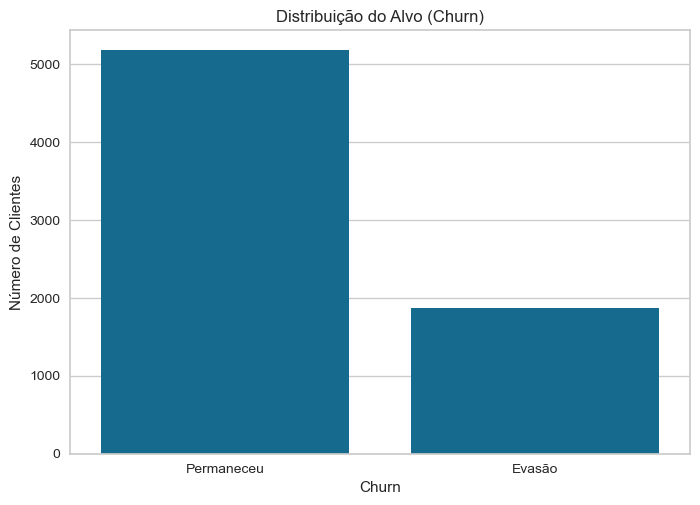

In [22]:
sns.countplot(data=df_clean, x='Churn')
plt.title('Distribuição do Alvo (Churn)')
plt.xticks([0, 1], ['Permaneceu', 'Evasão'])
plt.ylabel('Número de Clientes')

plt.show()

## Visão geral do alvo (Churn)

In [23]:
# Porcentagem
df_clean['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Como balancear os dados da variável alvo?

## Análise univariada: variáveis categóricas

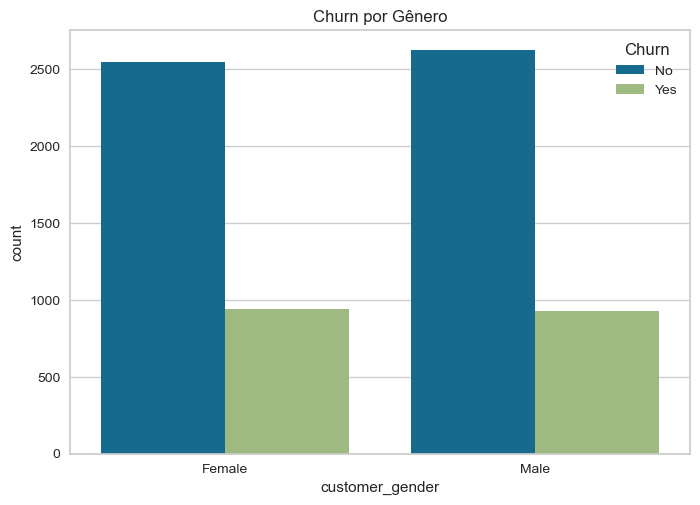

In [24]:
sns.countplot(x = df_clean.customer_gender.map({1: 'Female', 0: 'Male'}), hue = df_clean.Churn.map({1: 'Yes', 0: 'No'}))
plt.title('Churn por Gênero')
plt.show()

## Análise univariada: variáveis numéricas

In [25]:
bins = lt.get_bins_rule_sturges(df_clean.account_Charges_Monthly)
bins

3.323708872015396

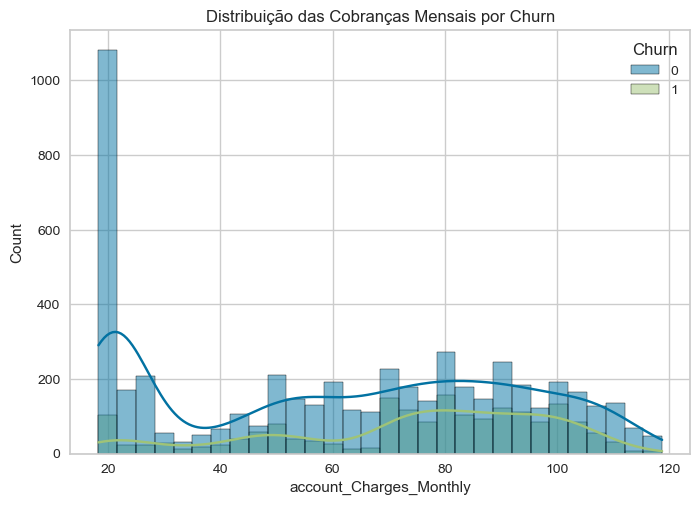

In [26]:
sns.histplot(data=df_clean, x='account_Charges_Monthly', hue='Churn', kde=True, binwidth=bins)
plt.title('Distribuição das Cobranças Mensais por Churn')
plt.show()

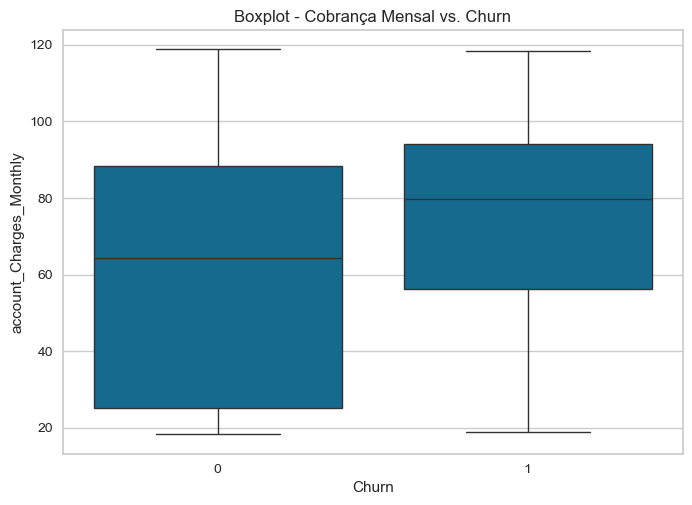

In [27]:
sns.boxplot(data=df_clean, x='Churn', y='account_Charges_Monthly')
plt.title('Boxplot - Cobrança Mensal vs. Churn')
plt.show()

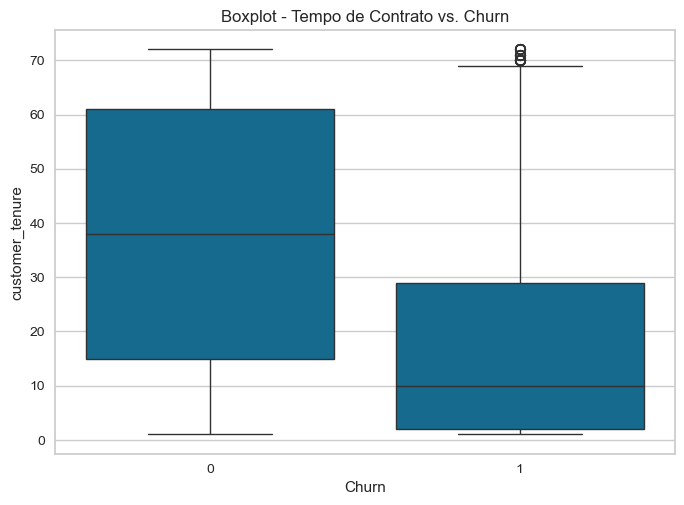

In [28]:
sns.boxplot(data=df_clean, x='Churn', y='customer_tenure')
plt.title('Boxplot - Tempo de Contrato vs. Churn')
plt.show()

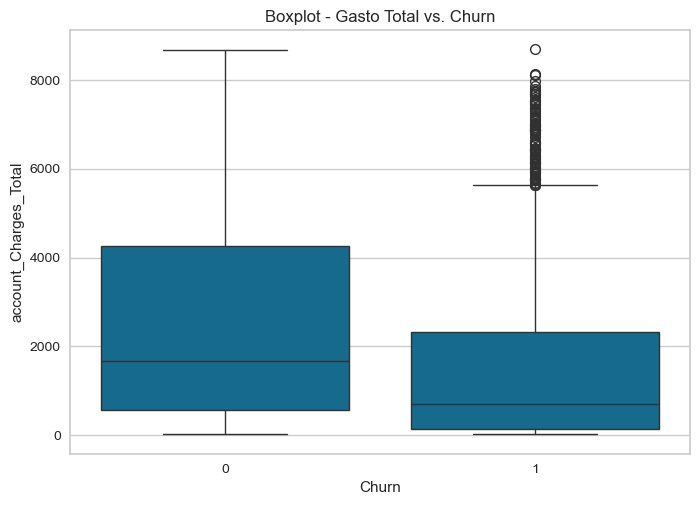

In [29]:
sns.boxplot(data=df_clean, x='Churn', y='account_Charges_Total')
plt.title('Boxplot - Gasto Total vs. Churn')
plt.show()

## Correlações

### Somente com variáveis numéricas:

In [30]:
colunas_analise = df_clean.select_dtypes(include=[np.number]).columns

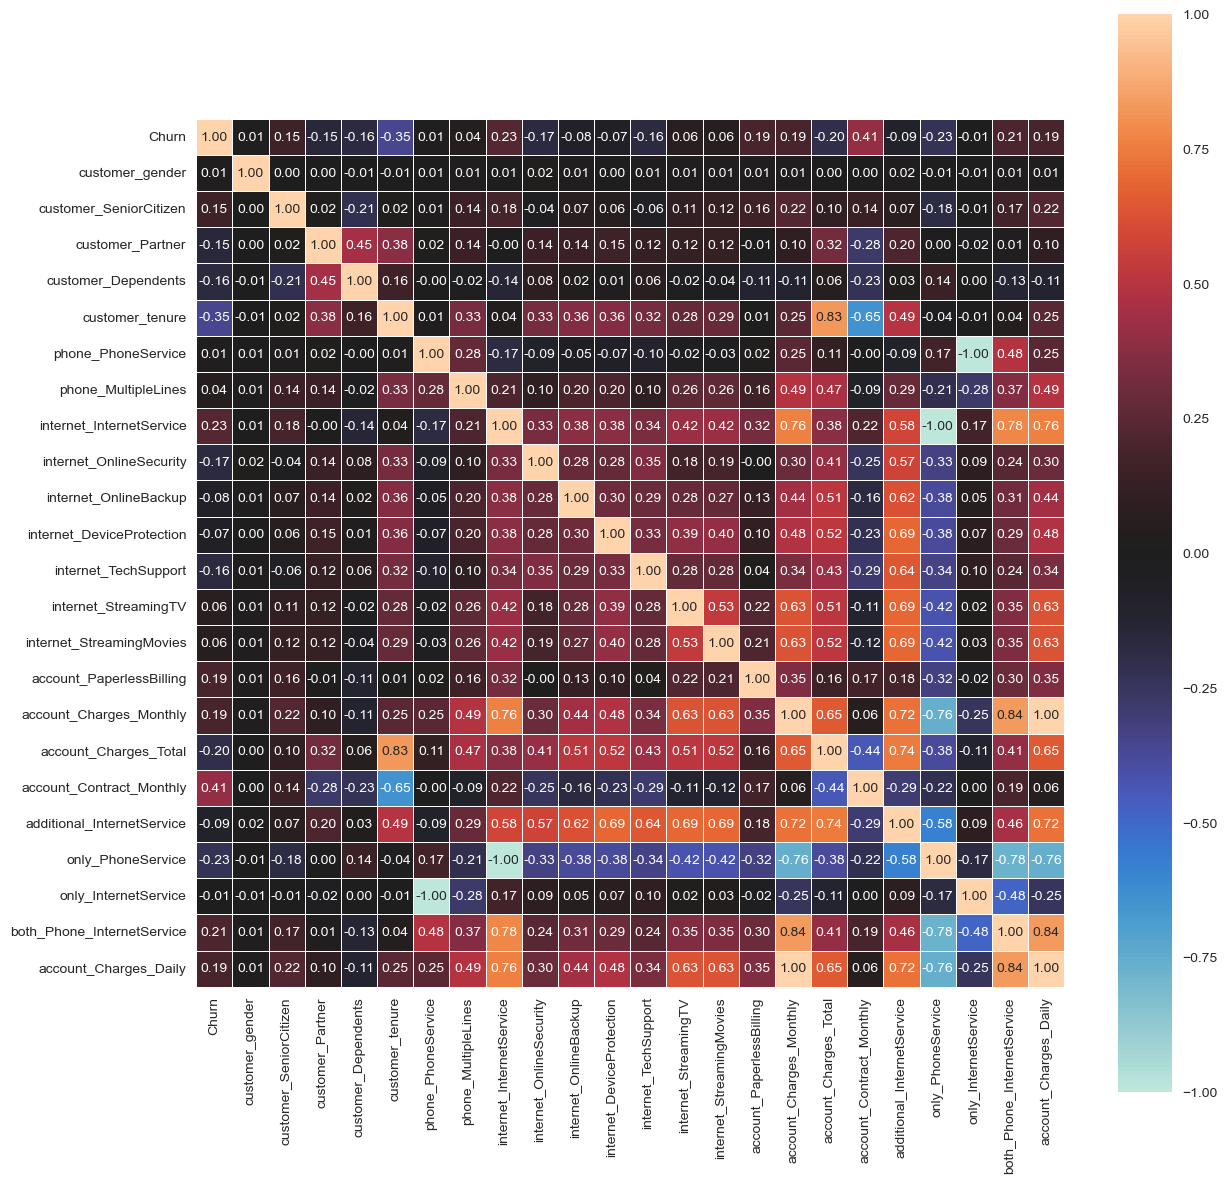

In [31]:
tml.graf_correlacao_variaveis(df_clean, colunas_analise, tam_figura=(14,14), tam_fonte=10).show()

### Correlação do tipo de serviço

In [32]:
colunas_analise = ['phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'only_PhoneService', 'only_InternetService', 'both_Phone_InternetService']

In [33]:
df_clean[colunas_analise].head()

,phone_PhoneService,phone_MultipleLines,internet_InternetService,only_PhoneService,only_InternetService,both_Phone_InternetService
0,1,0,1,0,0,1
1,1,1,1,0,0,1
2,1,0,1,0,0,1
3,1,0,1,0,0,1
4,1,0,1,0,0,1


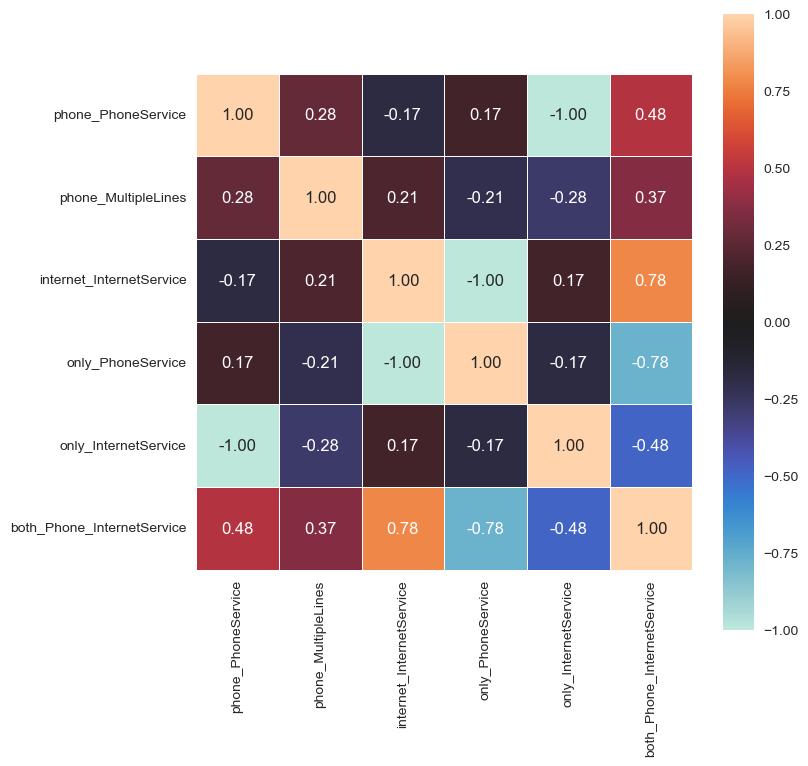

In [34]:
tml.graf_correlacao_variaveis(df_clean, colunas_analise).show()

In [35]:
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                    |    VIF |   tolerance |
|----------------------------+--------+-------------|
| const                      |   0.00 |      inf    |
| phone_PhoneService         | inf    |        0.00 |
| phone_MultipleLines        |   1.17 |        0.85 |
| internet_InternetService   | inf    |        0.00 |
| only_PhoneService          | inf    |        0.00 |
| only_InternetService       | inf    |        0.00 |
| both_Phone_InternetService | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [36]:
[colunas_analise.remove(x) for x in ['only_PhoneService', 'only_InternetService', 'both_Phone_InternetService']]
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                  |   VIF |   tolerance |
|--------------------------+-------+-------------|
| const                    | 16.89 |        0.06 |
| phone_PhoneService       |  1.15 |        0.87 |
| phone_MultipleLines      |  1.17 |        0.85 |
| internet_InternetService |  1.11 |        0.90 |


### Correlação de valores de serviço

In [37]:
colunas_analise = ['account_Charges_Monthly', 'account_Charges_Total', 'account_Charges_Daily', 'customer_tenure']

In [38]:
df_clean[colunas_analise].head()

,account_Charges_Monthly,account_Charges_Total,account_Charges_Daily,customer_tenure
0,65.6,593.30,2.186667,9
1,59.9,542.40,1.996667,9
2,73.9,280.85,2.463333,4
3,98.0,1237.85,3.266667,13
4,83.9,267.40,2.796667,3


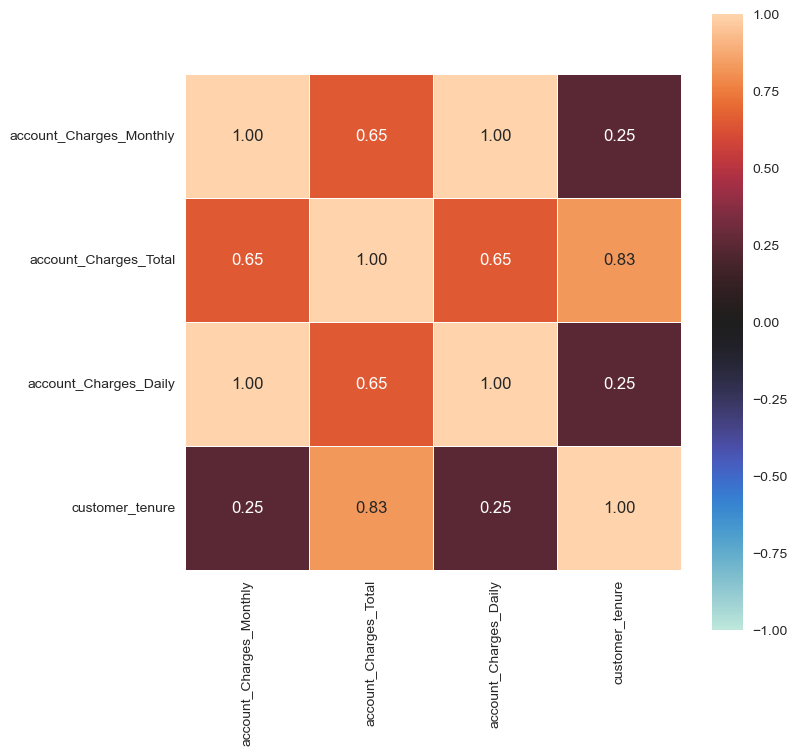

In [39]:
tml.graf_correlacao_variaveis(df_clean, colunas_analise).show()

#### Verificando fator de inflação de variância

✅ 2. Limiares comuns para suspeita de multicolinearidade

| Indicador                       | Limite comum    | Interpretação                            |
| ------------------------------- | --------------- | ---------------------------------------- |
| Correlação entre variáveis      | > 0.8 ou < -0.8 | Alta correlação direta ou inversa        |
| VIF (Variance Inflation Factor) | > 5 (ou 10)     | Indica potencial multicolinearidade      |
| Tolerância (1 / VIF)            | < 0.2           | Problema potencial de multicolinearidade |


In [40]:
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                 |    VIF |   tolerance |
|-------------------------+--------+-------------|
| const                   |  14.90 |        0.07 |
| account_Charges_Monthly | inf    |        0.00 |
| account_Charges_Total   |   9.51 |        0.11 |
| account_Charges_Daily   | inf    |        0.00 |
| customer_tenure         |   5.84 |        0.17 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [41]:
[colunas_analise.remove(x) for x in ['account_Charges_Daily']]
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                 |   VIF |   tolerance |
|-------------------------+-------+-------------|
| const                   | 14.90 |        0.07 |
| account_Charges_Monthly |  3.22 |        0.31 |
| account_Charges_Total   |  9.51 |        0.11 |
| customer_tenure         |  5.84 |        0.17 |


In [42]:
[colunas_analise.remove(x) for x in ['account_Charges_Total']]
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                 |   VIF |   tolerance |
|-------------------------+-------+-------------|
| const                   |  6.29 |        0.16 |
| account_Charges_Monthly |  1.07 |        0.94 |
| customer_tenure         |  1.07 |        0.94 |


### Correlação de características do cliente e da família

In [43]:
colunas_analise = ['customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents']

In [44]:
df_clean[colunas_analise].head()

,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents
0,1,0,1,1
1,0,0,0,0
2,0,0,0,0
3,0,1,1,0
4,1,1,1,0


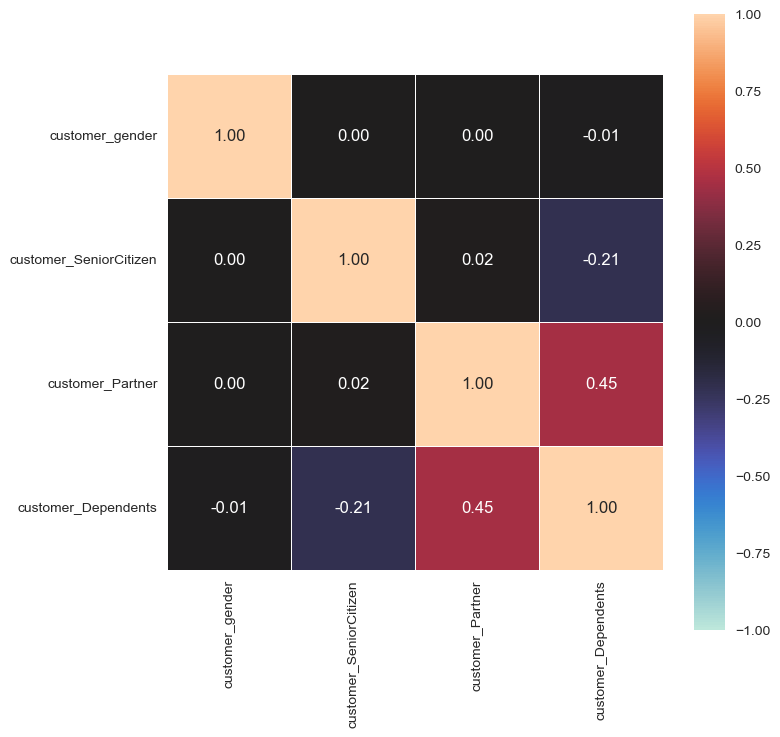

In [45]:
tml.graf_correlacao_variaveis(df_clean, colunas_analise).show()

#### Verificando fator de inflação de variância

In [46]:
lt.get_variance_inflation_factor(df_clean, colunas_analise, False)

,feature,VIF,tolerance
0,const,3.227360,0.309851
1,customer_gender,1.000167,0.999833
2,customer_SeniorCitizen,1.064282,0.939601
3,customer_Partner,1.278948,0.781893
4,customer_Dependents,1.338426,0.747146


### Correlação dos serviços adicionais de internet

In [47]:
colunas_analise = ['internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'additional_InternetService']

In [48]:
df_clean[colunas_analise].head()

,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,additional_InternetService
0,0,1,0,1,1,0,3
1,0,0,0,0,0,1,1
2,0,0,1,0,0,0,1
3,0,1,1,0,1,1,4
4,0,0,0,1,1,0,2


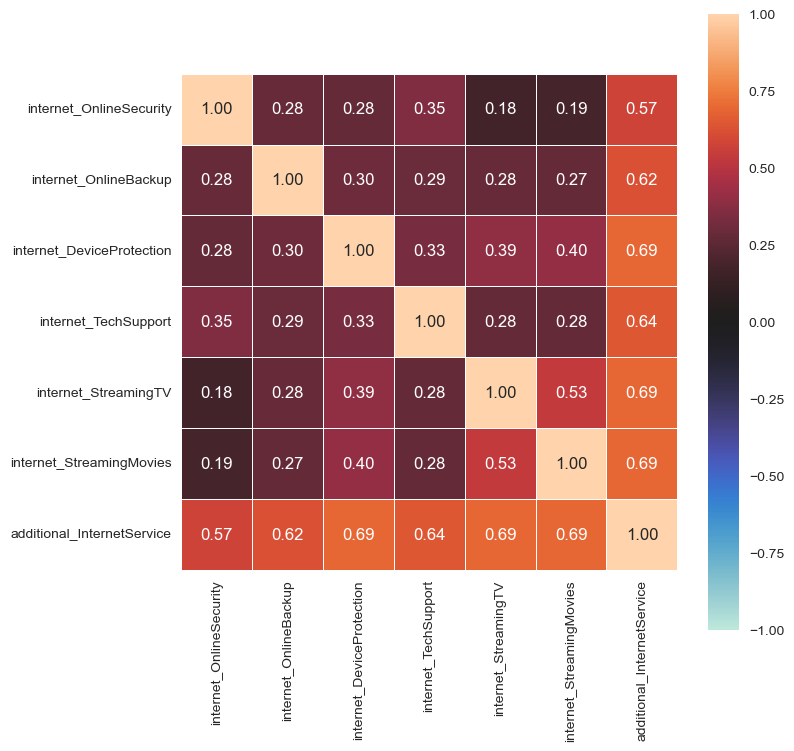

In [49]:
tml.graf_correlacao_variaveis(df_clean, colunas_analise).show()

#### Verificando fator de inflação de variância

In [50]:
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                    |    VIF |   tolerance |
|----------------------------+--------+-------------|
| const                      |   2.23 |        0.45 |
| internet_OnlineSecurity    | inf    |        0.00 |
| internet_OnlineBackup      | inf    |        0.00 |
| internet_DeviceProtection  | inf    |        0.00 |
| internet_TechSupport       | inf    |        0.00 |
| internet_StreamingTV       | inf    |        0.00 |
| internet_StreamingMovies   | inf    |        0.00 |
| additional_InternetService | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [51]:
[colunas_analise.remove(x) for x in [
        'internet_OnlineSecurity', 
        'internet_OnlineBackup', 
        'internet_DeviceProtection', 
        'internet_TechSupport', 
        'internet_StreamingTV', 
        'internet_StreamingMovies'
    ]]
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                    |   VIF |   tolerance |
|----------------------------+-------+-------------|
| const                      |  2.22 |        0.45 |
| additional_InternetService |  1.00 |        1.00 |


In [52]:
colunas_analise = ['internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'additional_InternetService']

In [53]:
[colunas_analise.remove(x) for x in ['additional_InternetService']]
lt.get_variance_inflation_factor(df_clean, colunas_analise)

| feature                   |   VIF |   tolerance |
|---------------------------+-------+-------------|
| const                     |  2.23 |        0.45 |
| internet_OnlineSecurity   |  1.22 |        0.82 |
| internet_OnlineBackup     |  1.22 |        0.82 |
| internet_DeviceProtection |  1.38 |        0.73 |
| internet_TechSupport      |  1.29 |        0.77 |
| internet_StreamingTV      |  1.51 |        0.66 |
| internet_StreamingMovies  |  1.52 |        0.66 |


# 📌 Estatística Descritiva e Inferencial

## Estatística Descritiva

### Medidas de tendência central e dispersão

In [54]:
df_dados.groupby('Churn')[['account_Charges_Monthly', 'customer_tenure']].describe().T

Churn                                    0            1
account_Charges_Monthly count  5174.000000  1869.000000
                        mean     61.265124    74.441332
                        std      31.092648    24.666053
                        min      18.250000    18.850000
                        25%      25.100000    56.150000
                        50%      64.425000    79.650000
                        75%      88.400000    94.200000
                        max     118.750000   118.350000
customer_tenure         count  5174.000000  1869.000000
                        mean     37.572091    17.979133
                        std      24.110507    19.531123
                        min       1.000000     1.000000
                        25%      15.000000     2.000000
                        50%      38.000000    10.000000
                        75%      61.000000    29.000000
                        max      72.000000    72.000000

In [55]:
lt.describe_full_df_segmented(df_dados, 'account_Charges_Monthly', 'Churn', extend_metrics=True)

E:\Local_Drive\Cursos Livres\ONE\06-Estatística e Machine Learning G8 - ONE\08-Challenge Telecom X - análise de evasão de clientes - Parte 2\TelecomX_parte2_BR\scripts\local_tools.py:142: RuntimeWarning: invalid value encountered in scalar divide
  coefficient_variation = lambda x: pd.Series.std(x) / pd.Series.mean(x)
E:\Local_Drive\Cursos Livres\ONE\06-Estatística e Machine Learning G8 - ONE\08-Challenge Telecom X - análise de evasão de clientes - Parte 2\TelecomX_parte2_BR\scripts\local_tools.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ampl_over_avg = lambda x: amplitude(x) / pd.Series.mean(x)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be

,0,1
account_Charges_Monthly,,
count,5174,1869
count_isnull,0,0
%_count_isnull,0.0,0.0
count_zero,0,0
count_nonzero,5174,1869
count_positive,5174,1869
count_negative,0,0
count_unique,1460,910
mean,61.265124,74.441332


### Coeficiente de variação, assimetria, normalidade e variabilidade

In [56]:
colunas_analise = ['account_Charges_Monthly', 'account_Charges_Total', 'customer_tenure']
print(f'Observações: {len(df_clean)}')
for c in colunas_analise:
    cv = variation(df_clean[c]) # quanto maior, maior a dispersão relativa
    sk = skew(df_clean[c]) # assimetria da distribuição
    kt = kurtosis(df_clean[c])
    sp_t, p = shapiro(df_clean[c])
    et = entropy(df_clean[c])
    print(f'\n{c}:')
    print(f'Coeficiente de Variação: {cv:.2f}')
    print(f'Assimetria (Skew): {sk:.2f}')
    print(f'Kurtosis (Skew): {kt:.2f}')
    print(f'Shapiro Wilk - Estatística: {sp_t:.2f}. P-value: {p:.2f}.')
    print(f'Entropia: {et:.2f}')
    

Observações: 7043

account_Charges_Monthly:
Coeficiente de Variação: 0.46
Assimetria (Skew): -0.22
Kurtosis (Skew): -1.26
Shapiro Wilk - Estatística: 0.92. P-value: 0.00.
Entropia: 8.74

account_Charges_Total:
Coeficiente de Variação: 0.99
Assimetria (Skew): 0.96
Kurtosis (Skew): -0.23
Shapiro Wilk - Estatística: 0.86. P-value: 0.00.
Entropia: 8.37

customer_tenure:
Coeficiente de Variação: 0.76
Assimetria (Skew): 0.24
Kurtosis (Skew): -1.39
Shapiro Wilk - Estatística: 0.90. P-value: 0.00.
Entropia: 8.53


C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)


| Variável                      | Coef. Variação (CV)       | Assimetria (Skew)                              | Curtose                                       | Normalidade (Shapiro-Wilk) | Entropia                | Observações e Impacto no ML                                                                                                                     | Necessidade de Tratamento                                                                           |
| ----------------------------- | ------------------------- | ---------------------------------------------- | --------------------------------------------- | -------------------------- | ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| **account\_Charges\_Monthly** | 0.46 (baixa dispersão)    | -0.22 (quase simétrica, leve cauda à esquerda) | -1.26 (distribuição mais achatada que normal) | p < 0.05 → não normal      | 8.74 (alta diversidade) | Boa estabilidade, pouca variabilidade relativa; ausência de normalidade não é problema grave para modelos baseados em árvore.                   | Escalonar apenas se usar modelos sensíveis a escala (ex.: regressão logística, SVM, redes neurais). |
| **account\_Charges\_Total**   | 0.99 (alta dispersão)     | 0.96 (assimetria positiva moderada)            | -0.23 (levemente achatada)                    | p < 0.05 → não normal      | 8.37 (alta diversidade) | Alta dispersão e assimetria indicam que poucos clientes concentram valores altos; pode ser preditiva de churn se associada a tempo de contrato. | Avaliar log-transform ou binning se usar modelos lineares; árvores lidam bem.                       |
| **customer\_tenure**          | 0.76 (moderada dispersão) | 0.24 (quase simétrica)                         | -1.39 (muito achatada)                        | p < 0.05 → não normal      | 8.53 (alta diversidade) | Distribuição relativamente equilibrada, mas achatada; mostra clientes distribuídos em várias faixas de tempo.                                   | Pode manter contínua; binning pode ser útil se relação com churn não for linear.                    |


📌 Principais pontos para churn

    Nenhuma variável é normal — mas para modelos como XGBoost, LightGBM ou Random Forest, isso não é um problema.

    account_Charges_Total é a mais assimétrica → pode precisar de transformação apenas se usar modelos sensíveis à escala ou regressões.

    customer_tenure já foi binada antes por você — manter bins pode melhorar interpretação, mas perde um pouco da granularidade.

    CV mostra que account_Charges_Monthly é mais estável, enquanto account_Charges_Total é bem mais volátil (potencialmente mais informativo).

    Entropia alta em todas indica boa variabilidade de valores (bom para ML).

### Crição de binned otimizados para variáveis numéricas

#### Deletar colunas bins criadas anteriormente e criar novas bins otimizadas

In [57]:
df_clean.drop(columns=['customer_tenure_bins', 'account_Charges_Monthly_bins', 'account_Charges_Total_bins'], inplace=True)

In [58]:
df_clean['tenure_bin'] = lt.optimal_bins(df_clean, 'customer_tenure', 'Churn')
df_clean['charges_monthly_bin'] = lt.optimal_bins(df_clean, 'account_Charges_Monthly', 'Churn')
df_clean['charges_total_bin'] = lt.optimal_bins(df_clean, 'account_Charges_Total', 'Churn')

In [59]:
df_clean.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,internet_Service_Description,account_Contract_Monthly,additional_InternetService,only_PhoneService,only_InternetService,both_Phone_InternetService,account_Charges_Daily,tenure_bin,charges_monthly_bin,charges_total_bin
0,0,1,0,1,1,9,1,0,1,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,DSL,0,3,0,0,1,2.186667,"[5.50, 10.50)","[27.68, 68.83)","[547.73, 1182.80)"
1,0,0,0,0,0,9,1,1,1,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,DSL,1,1,0,0,1,1.996667,"[5.50, 10.50)","[27.68, 68.83)","[347.90, 547.73)"
2,1,0,0,0,0,4,1,0,1,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,Fiber optic,1,1,0,0,1,2.463333,"[1.50, 5.50)","[68.83, inf)","[198.05, 347.90)"
3,1,0,1,1,0,13,1,0,1,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,Fiber optic,1,4,0,0,1,3.266667,"[10.50, 16.50)","[68.83, inf)","[1182.80, 3273.68)"
4,1,1,1,1,0,3,1,0,1,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,Fiber optic,1,2,0,0,1,2.796667,"[1.50, 5.50)","[68.83, inf)","[198.05, 347.90)"


In [60]:
df_clean = lt.adjust_column_names(df_clean)

## Estatística Inferencial

### Teste Qui-Quadrado (duas variáveis categóricas)

In [61]:
variaveis_categoricas, dominios = lt.get_columns_categorical(df_clean, LIMITE_CATEGORICAS)

In [62]:
list(zip(variaveis_categoricas, dominios))

[('Churn', [0, 1]),
 ('customer_gender', [0, 1]),
 ('customer_SeniorCitizen', [0, 1]),
 ('customer_Partner', [0, 1]),
 ('customer_Dependents', [0, 1]),
 ('phone_PhoneService', [0, 1]),
 ('phone_MultipleLines', [0, 1]),
 ('internet_InternetService', [0, 1]),
 ('internet_OnlineSecurity', [0, 1]),
 ('internet_OnlineBackup', [0, 1]),
 ('internet_DeviceProtection', [0, 1]),
 ('internet_TechSupport', [0, 1]),
 ('internet_StreamingTV', [0, 1]),
 ('internet_StreamingMovies', [0, 1]),
 ('account_Contract', ['Month-to-month', 'One year', 'Two year']),
 ('account_PaperlessBilling', [0, 1]),
 ('account_PaymentMethod',
  ['Bank transfer (automatic)',
   'Credit card (automatic)',
   'Electronic check',
   'Mailed check']),
 ('internet_Service_Description', ['DSL', 'Fiber optic', 'No']),
 ('account_Contract_Monthly', [0, 1]),
 ('additional_InternetService', [0, 1, 2, 3, 4, 5, 6]),
 ('only_PhoneService', [0, 1]),
 ('only_InternetService', [0, 1]),
 ('both_Phone_InternetService', [0, 1]),
 ('tenure_bi

In [63]:
lt.get_chi_square(df_clean, variaveis_categoricas[0], variaveis_categoricas[1:])

,variable,chi_square,p_value,dof,significance
13,account_Contract,1184.5966,0.000000,2,1
17,account_Contract_Monthly,1153.9717,0.000000,1,1
14,account_PaperlessBilling,258.2776,0.000000,1,1
15,account_PaymentMethod,648.1423,0.000000,3,1
18,additional_InternetService,390.9430,0.000000,6,1
21,both_Phone_InternetService,309.5357,0.000000,1,1
23,charges_monthly_bin,419.8623,0.000000,4,1
24,charges_total_bin,491.0968,0.000000,9,1
3,customer_Dependents,189.1292,0.000000,1,1
2,customer_Partner,158.7334,0.000000,1,1


### Teste T de médias (variável numérica vs binária)

In [64]:
variaveis_numericas = lt.get_columns_numeric(df_clean, LIMITE_CATEGORICAS)
variaveis_numericas

['account_Charges_Total',
 'account_Charges_Monthly',
 'account_Charges_Daily',
 'customer_tenure']

In [65]:
lt.get_ttest_ind(df_clean, 'Churn', variaveis_numericas)

,variable,t_stat,p_value,significance
2,account_Charges_Daily,-16.5367,0.0,1
1,account_Charges_Monthly,-16.5367,0.0,1
0,account_Charges_Total,16.9808,0.0,1
3,customer_tenure,31.5864,0.0,1


#### Verificação de multicolinearidade com VIF

In [66]:
lt.get_variance_inflation_factor(df_clean, variaveis_numericas)

| feature                 |    VIF |   tolerance |
|-------------------------+--------+-------------|
| const                   |  14.90 |        0.07 |
| account_Charges_Total   |   9.51 |        0.11 |
| account_Charges_Monthly | inf    |        0.00 |
| account_Charges_Daily   | inf    |        0.00 |
| customer_tenure         |   5.84 |        0.17 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


✅ Conclusão

    Sim, com um VIF > 9, a variável account_Charges_Total apresenta forte multicolinearidade com outras variáveis do modelo.

    Causa provável:
    account_Charges_Total é provavelmente o produto de account_Charges_Monthly * customer_tenure, ou algo muito próximo disso. Portanto, ela está matematicamente associada às outras duas, o que gera colinearidade.

| Variável                  | VIF      | Interpretação                       |
| ------------------------- | -------- | ----------------------------------- |
| `const`                   | 14.90    | Desconsiderar, é apenas a constante |
| `account_Charges_Total`   | **9.51** | 🚨 Alta multicolinearidade          |
| `customer_tenure`         | 5.84     | Moderada multicolinearidade         |
| `account_Charges_Monthly` | 3.22     | Aceitável                           |



In [67]:
temp = variaveis_numericas.copy()
[temp.remove(x) for x in ['account_Charges_Total', 'account_Charges_Daily']]
lt.get_variance_inflation_factor(df_clean, temp)

| feature                 |   VIF |   tolerance |
|-------------------------+-------+-------------|
| const                   |  6.29 |        0.16 |
| account_Charges_Monthly |  1.07 |        0.94 |
| customer_tenure         |  1.07 |        0.94 |


### Fator de inflação de variância (VIF)

#### Colunas binárias

In [68]:
variaveis_binarias = lt.get_columns_binary(df_clean)
variaveis_binarias[0]

'Churn'

In [69]:
# Colunas binárias sem Churn
variaveis_binarias[1:]

['customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_PaperlessBilling',
 'account_Contract_Monthly',
 'only_PhoneService',
 'only_InternetService',
 'both_Phone_InternetService']

In [70]:
temp = variaveis_binarias.copy()
[temp.remove(x) for x in [
    'Churn', 'customer_gender','only_PhoneService', 'only_InternetService', 'both_Phone_InternetService', 'internet_OnlineSecurity', 
        'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 
        'internet_StreamingMovies',
]]

[None, None, None, None, None, None, None, None, None, None, None]

In [71]:
lt.get_variance_inflation_factor(df_clean, temp)

| feature                  |   VIF |   tolerance |
|--------------------------+-------+-------------|
| const                    | 19.20 |        0.05 |
| customer_SeniorCitizen   |  1.12 |        0.90 |
| customer_Partner         |  1.37 |        0.73 |
| customer_Dependents      |  1.37 |        0.73 |
| phone_PhoneService       |  1.17 |        0.86 |
| phone_MultipleLines      |  1.25 |        0.80 |
| internet_InternetService |  1.30 |        0.77 |
| account_PaperlessBilling |  1.16 |        0.87 |
| account_Contract_Monthly |  1.20 |        0.83 |


## Análise de multicolinearidade de variáveis derivadas

In [72]:
variaveis_categoricas, dominios = lt.get_columns_categorical(df_clean, LIMITE_CATEGORICAS)

In [73]:
variaveis_multi_categoricas = list(set(variaveis_categoricas).difference(variaveis_binarias))
variaveis_multi_categoricas

['charges_total_bin',
 'additional_InternetService',
 'account_Contract',
 'internet_Service_Description',
 'tenure_bin',
 'account_PaymentMethod',
 'charges_monthly_bin']

In [74]:
lista_otimizada = variaveis_multi_categoricas.copy()
lista_otimizada.extend(['customer_tenure', 'account_Charges_Monthly', 'account_Contract_Monthly', 'internet_InternetService'])

In [75]:
variaveis_multi_categoricas

['charges_total_bin',
 'additional_InternetService',
 'account_Contract',
 'internet_Service_Description',
 'tenure_bin',
 'account_PaymentMethod',
 'charges_monthly_bin']

In [76]:
lista_otimizada

['charges_total_bin',
 'additional_InternetService',
 'account_Contract',
 'internet_Service_Description',
 'tenure_bin',
 'account_PaymentMethod',
 'charges_monthly_bin',
 'customer_tenure',
 'account_Charges_Monthly',
 'account_Contract_Monthly',
 'internet_InternetService']

In [77]:
temp_ohe = pd.get_dummies(df_clean[lista_otimizada], columns=variaveis_multi_categoricas, drop_first=False, dtype=int)

### Correlação dos meses de contratos

In [78]:
colunas_analise = (lt.filter_startswith(temp_ohe.columns, 'tenure_bin_'))

In [79]:
temp_ohe[colunas_analise].head()

,"tenure_bin_(-inf, 1.50)","tenure_bin_[1.50, 5.50)","tenure_bin_[10.50, 16.50)","tenure_bin_[16.50, 22.50)","tenure_bin_[22.50, 33.50)","tenure_bin_[33.50, 43.50)","tenure_bin_[43.50, 49.50)","tenure_bin_[49.50, 59.50)","tenure_bin_[5.50, 10.50)","tenure_bin_[59.50, 70.50)","tenure_bin_[70.50, inf)"
0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0


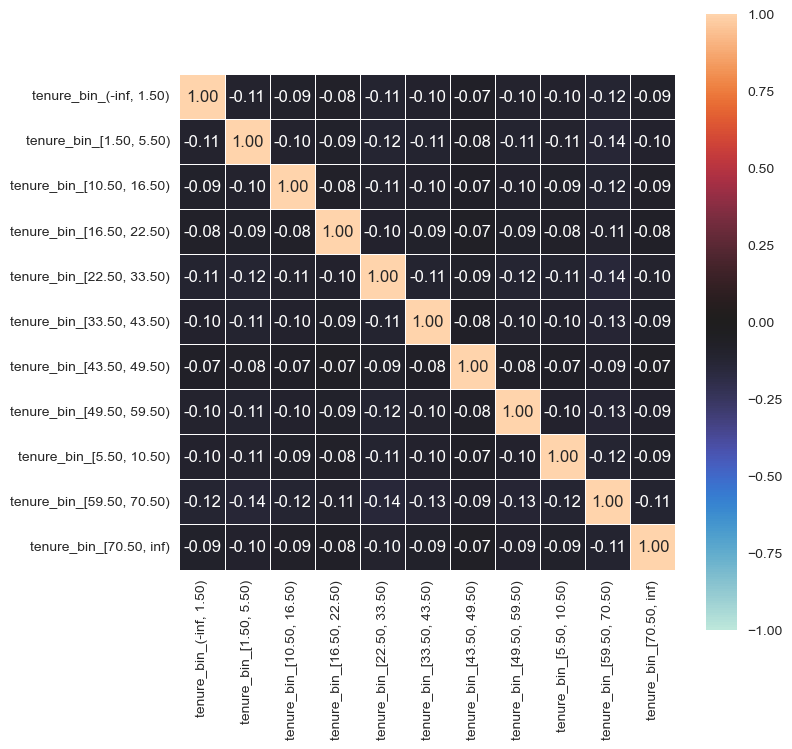

In [80]:
tml.graf_correlacao_variaveis(temp_ohe, colunas_analise).show()

#### Verificando fator de inflação de variância

In [81]:
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                   |    VIF |   tolerance |
|---------------------------+--------+-------------|
| const                     |   0.00 |      inf    |
| tenure_bin_(-inf, 1.50)   | inf    |        0.00 |
| tenure_bin_[1.50, 5.50)   | inf    |        0.00 |
| tenure_bin_[10.50, 16.50) | inf    |        0.00 |
| tenure_bin_[16.50, 22.50) | inf    |        0.00 |
| tenure_bin_[22.50, 33.50) | inf    |        0.00 |
| tenure_bin_[33.50, 43.50) | inf    |        0.00 |
| tenure_bin_[43.50, 49.50) | inf    |        0.00 |
| tenure_bin_[49.50, 59.50) | inf    |        0.00 |
| tenure_bin_[5.50, 10.50)  | inf    |        0.00 |
| tenure_bin_[59.50, 70.50) | inf    |        0.00 |
| tenure_bin_[70.50, inf)   | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Correlação dos custos mensais

In [82]:
colunas_analise = (lt.filter_startswith(temp_ohe.columns, 'charges_monthly_bin_'))

In [83]:
temp_ohe[colunas_analise].head()

,"charges_monthly_bin_(-inf, 19.93)","charges_monthly_bin_[19.93, 20.88)","charges_monthly_bin_[20.88, 27.68)","charges_monthly_bin_[27.68, 68.83)","charges_monthly_bin_[68.83, inf)"
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


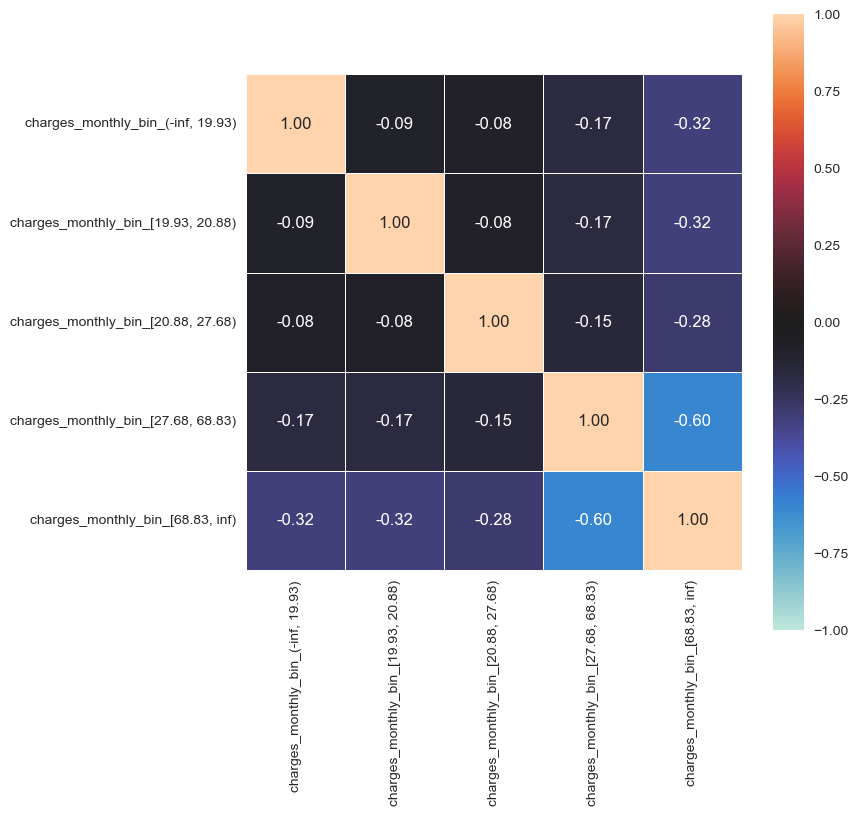

In [84]:
tml.graf_correlacao_variaveis(temp_ohe, colunas_analise).show()

#### Verificando fator de inflação de variância

In [85]:
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                            |    VIF |   tolerance |
|------------------------------------+--------+-------------|
| const                              |   0.00 |      inf    |
| charges_monthly_bin_(-inf, 19.93)  | inf    |        0.00 |
| charges_monthly_bin_[19.93, 20.88) | inf    |        0.00 |
| charges_monthly_bin_[20.88, 27.68) | inf    |        0.00 |
| charges_monthly_bin_[27.68, 68.83) | inf    |        0.00 |
| charges_monthly_bin_[68.83, inf)   | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Correlação dos custos totais

In [86]:
colunas_analise = (lt.filter_startswith(temp_ohe.columns, 'charges_total_bin_'))

In [87]:
temp_ohe[colunas_analise].head()

,"charges_total_bin_(-inf, 96.62)","charges_total_bin_[1182.80, 3273.68)","charges_total_bin_[198.05, 347.90)","charges_total_bin_[3273.68, 4838.38)","charges_total_bin_[347.90, 547.73)","charges_total_bin_[4838.38, 5644.60)","charges_total_bin_[547.73, 1182.80)","charges_total_bin_[5644.60, 6623.50)","charges_total_bin_[6623.50, inf)","charges_total_bin_[96.62, 198.05)"
0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0


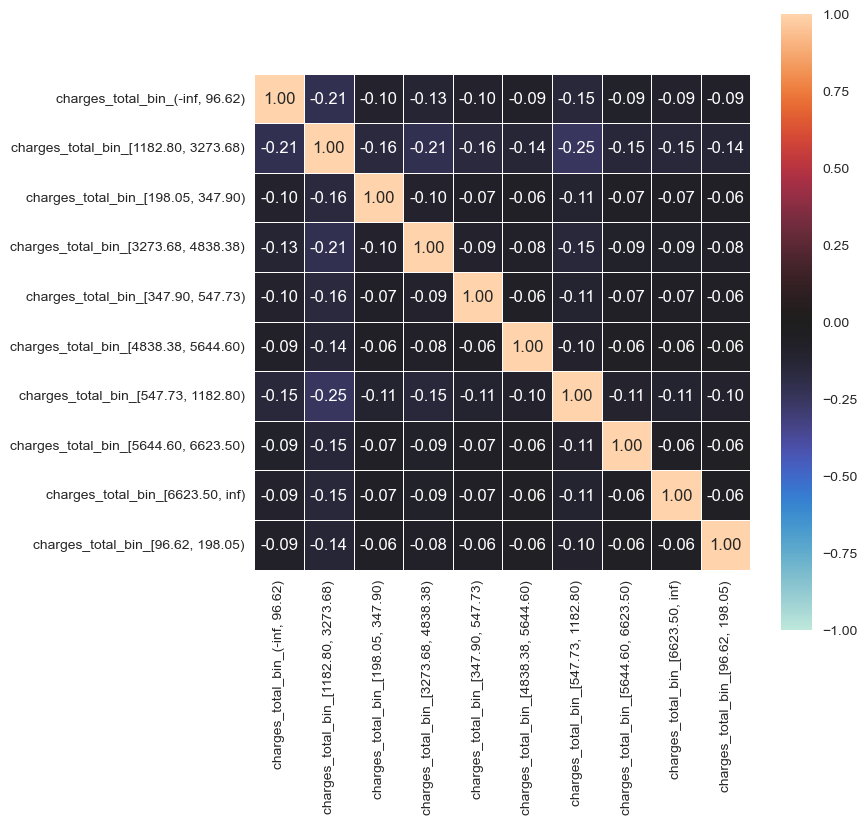

In [88]:
tml.graf_correlacao_variaveis(temp_ohe, colunas_analise).show()

#### Verificando fator de inflação de variância

In [89]:
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                              |    VIF |   tolerance |
|--------------------------------------+--------+-------------|
| const                                |   0.00 |      inf    |
| charges_total_bin_(-inf, 96.62)      | inf    |        0.00 |
| charges_total_bin_[1182.80, 3273.68) | inf    |        0.00 |
| charges_total_bin_[198.05, 347.90)   | inf    |        0.00 |
| charges_total_bin_[3273.68, 4838.38) | inf    |        0.00 |
| charges_total_bin_[347.90, 547.73)   | inf    |        0.00 |
| charges_total_bin_[4838.38, 5644.60) | inf    |        0.00 |
| charges_total_bin_[547.73, 1182.80)  | inf    |        0.00 |
| charges_total_bin_[5644.60, 6623.50) | inf    |        0.00 |
| charges_total_bin_[6623.50, inf)     | inf    |        0.00 |
| charges_total_bin_[96.62, 198.05)    | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Correlação dos Serviços de Internet

In [90]:
colunas_analise = ['internet_InternetService', 'internet_Service_Description_DSL',
       'internet_Service_Description_Fiber optic',
       'internet_Service_Description_No']

In [91]:
temp_ohe[colunas_analise].head()

,internet_InternetService,internet_Service_Description_DSL,internet_Service_Description_Fiber optic,internet_Service_Description_No
0,1,1,0,0
1,1,1,0,0
2,1,0,1,0
3,1,0,1,0
4,1,0,1,0


In [92]:
temp_ohe[colunas_analise].query("`internet_Service_Description_DSL` == 0 and `internet_Service_Description_Fiber optic` == 0").head()

,internet_InternetService,internet_Service_Description_DSL,internet_Service_Description_Fiber optic,internet_Service_Description_No
20,0,0,0,1
23,0,0,0,1
24,0,0,0,1
27,0,0,0,1
28,0,0,0,1


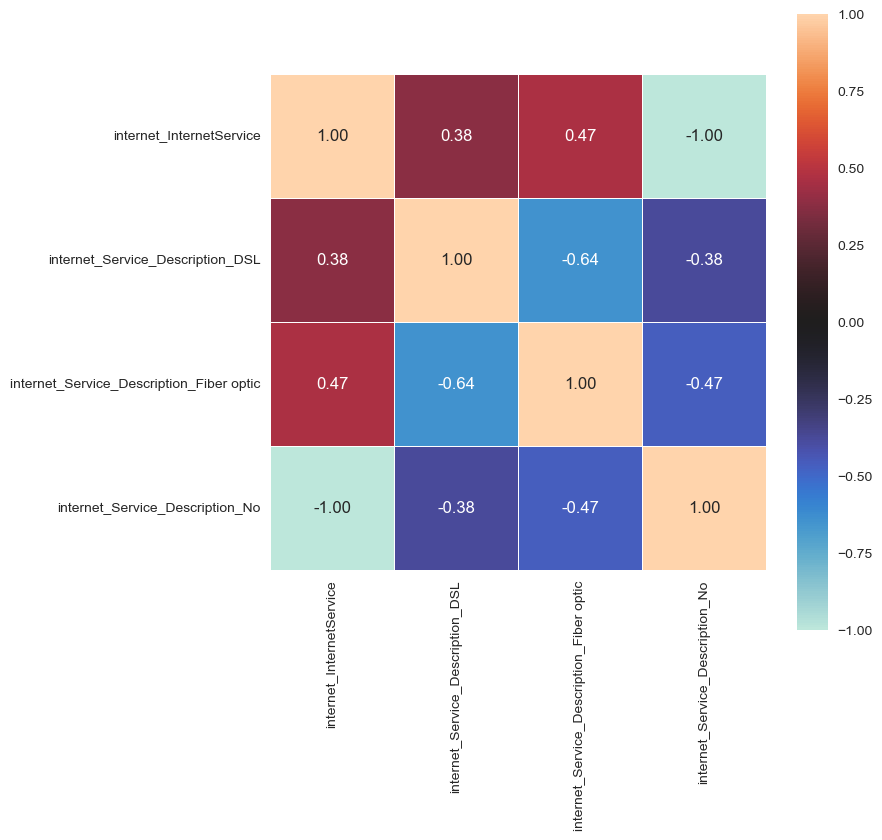

In [93]:
tml.graf_correlacao_variaveis(temp_ohe, colunas_analise).show()

#### Verificando fator de inflação de variância

In [94]:
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                                  |    VIF |   tolerance |
|------------------------------------------+--------+-------------|
| const                                    |   0.00 |      inf    |
| internet_InternetService                 | inf    |        0.00 |
| internet_Service_Description_DSL         | inf    |        0.00 |
| internet_Service_Description_Fiber optic | inf    |        0.00 |
| internet_Service_Description_No          | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


#### Seleção de fatures através da correlação

In [95]:
[colunas_analise.remove(x) for x in ['internet_Service_Description_No', 'internet_InternetService']]
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                                  |   VIF |   tolerance |
|------------------------------------------+-------+-------------|
| const                                    |  4.62 |        0.22 |
| internet_Service_Description_DSL         |  1.70 |        0.59 |
| internet_Service_Description_Fiber optic |  1.70 |        0.59 |


### Correlação dos Tipos de Contratos

In [96]:
colunas_analise = ['account_Contract_Monthly', 'account_Contract_Month-to-month',
       'account_Contract_One year', 'account_Contract_Two year']

In [97]:
temp_ohe[colunas_analise].head()

,account_Contract_Monthly,account_Contract_Month-to-month,account_Contract_One year,account_Contract_Two year
0,0,0,1,0
1,1,1,0,0
2,1,1,0,0
3,1,1,0,0
4,1,1,0,0


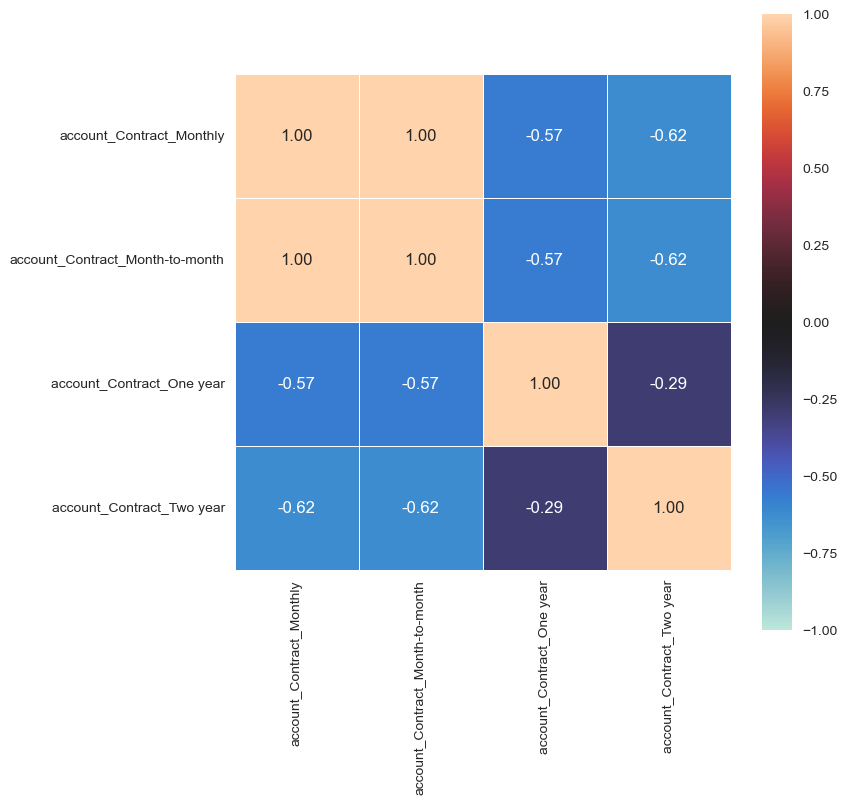

In [98]:
tml.graf_correlacao_variaveis(temp_ohe, colunas_analise).show()

#### Verificando fator de inflação de variância

In [99]:
lt.get_variance_inflation_factor(temp_ohe, colunas_analise)

| feature                         |    VIF |   tolerance |
|---------------------------------+--------+-------------|
| const                           |   0.00 |      inf    |
| account_Contract_Monthly        | inf    |        0.00 |
| account_Contract_Month-to-month | inf    |        0.00 |
| account_Contract_One year       | inf    |        0.00 |
| account_Contract_Two year       | inf    |        0.00 |


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## ANOVA - Análise de Variáveis independentes (categóricas x numéricas)

In [100]:
variaveis_categoricas, dominios = lt.get_columns_categorical(df_clean, LIMITE_CATEGORICAS)

In [101]:
variaveis_multi_categoricas = list(set(variaveis_categoricas).difference(variaveis_binarias))
variaveis_multi_categoricas

['charges_total_bin',
 'additional_InternetService',
 'account_Contract',
 'internet_Service_Description',
 'tenure_bin',
 'account_PaymentMethod',
 'charges_monthly_bin']

In [102]:
lt.print_tabulate_df(lt.get_anova_levene_test(df_clean, 'anova', ['account_Charges_Total'], variaveis_multi_categoricas))

| variable_numerical    | categorical                  |     stat |   p_value |   significance |
|-----------------------+------------------------------+----------+-----------+----------------|
| account_Charges_Total | charges_total_bin            | 25815.79 |      0.00 |              1 |
| account_Charges_Total | additional_InternetService   |  1539.41 |      0.00 |              1 |
| account_Charges_Total | account_Contract             |   920.59 |      0.00 |              1 |
| account_Charges_Total | internet_Service_Description |   801.08 |      0.00 |              1 |
| account_Charges_Total | tenure_bin                   |  1499.61 |      0.00 |              1 |
| account_Charges_Total | account_PaymentMethod        |   329.12 |      0.00 |              1 |
| account_Charges_Total | charges_monthly_bin          |   655.70 |      0.00 |              1 |


### Verificar Homogeneidade de variâncias (homocedasticidade)

#### Teste de Levene

Use o teste de Levene:

Se p < 0.05, as variâncias são diferentes → nesse caso, prefira o teste de Welch ANOVA (statsmodels ou pingouin), que é robusto a isso.

| Etapa                        | Resultado | Ação recomendada                                   |
| ---------------------------- | --------- | -------------------------------------------------- |
| ANOVA (`f_oneway`)           | p < 0.05  | Há diferença entre grupos                          |
| Teste de Levene (variâncias) | p < 0.05  | Variâncias diferentes → ANOVA tradicional inválida |
| Alternativa                  | —         | Use **Welch ANOVA** e **Games-Howell**             |


In [103]:
lt.print_tabulate_df(lt.get_anova_levene_test(df_clean, 'levene', ['account_Charges_Total'], variaveis_multi_categoricas))

| variable_numerical    | categorical                  |    stat |   p_value |   significance |
|-----------------------+------------------------------+---------+-----------+----------------|
| account_Charges_Total | charges_total_bin            |  660.59 |      0.00 |              1 |
| account_Charges_Total | additional_InternetService   |  311.14 |      0.00 |              1 |
| account_Charges_Total | account_Contract             |  561.55 |      0.00 |              1 |
| account_Charges_Total | internet_Service_Description | 1188.04 |      0.00 |              1 |
| account_Charges_Total | tenure_bin                   |  481.11 |      0.00 |              1 |
| account_Charges_Total | account_PaymentMethod        |  220.76 |      0.00 |              1 |
| account_Charges_Total | charges_monthly_bin          |  962.41 |      0.00 |              1 |


### Welch ANOVA e Games-Howell Post-hoc

In [104]:
lt.get_welch_anova_test(df_clean, 'Churn', variaveis_multi_categoricas)

,dv,Source,ddof1,ddof2,F,p-unc,np2
0,Churn,charges_total_bin,9,2126.324172,54.562886,0.0,0.069728
1,Churn,additional_InternetService,6,2142.684596,87.403294,0.0,0.055508
2,Churn,account_Contract,2,3695.823231,1001.222766,0.0,0.168195
3,Churn,internet_Service_Description,2,4563.008800,481.561511,0.0,0.103977
4,Churn,tenure_bin,10,2616.144611,160.897846,0.0,0.144754
5,Churn,account_PaymentMethod,3,3809.606234,201.281087,0.0,0.092026
6,Churn,charges_monthly_bin,4,1712.077501,157.802658,0.0,0.059614


In [105]:
lt.get_gameshowell_test(df_clean, 'Churn', variaveis_multi_categoricas)

,dv,between,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Churn,charges_total_bin,"(-inf, 96.62)","[1182.80, 3273.68)",0.527812,0.227647,0.300165,0.020123,14.916277,1334.728096,0.0,0.673467
1,Churn,charges_total_bin,"(-inf, 96.62)","[198.05, 347.90)",0.527812,0.340471,0.187341,0.028113,6.663959,1013.921168,0.0,0.381728
2,Churn,charges_total_bin,"(-inf, 96.62)","[3273.68, 4838.38)",0.527812,0.169385,0.358427,0.022027,16.271979,1499.524245,0.0,0.810033
3,Churn,charges_total_bin,"(-inf, 96.62)","[347.90, 547.73)",0.527812,0.277657,0.250155,0.027285,9.168308,1043.690026,0.0,0.519130
4,Churn,charges_total_bin,"(-inf, 96.62)","[4838.38, 5644.60)",0.527812,0.163539,0.364273,0.026003,14.008704,950.052986,0.0,0.786745
...,...,...,...,...,...,...,...,...,...,...,...,...
138,Churn,charges_monthly_bin,"[19.93, 20.88)","[27.68, 68.83)",0.078671,0.227893,-0.149222,0.015213,-9.809015,1543.337343,0.0,-0.385333
139,Churn,charges_monthly_bin,"[19.93, 20.88)","[68.83, inf)",0.078671,0.356343,-0.277672,0.013714,-20.246675,1210.831687,0.0,-0.607699
140,Churn,charges_monthly_bin,"[20.88, 27.68)","[27.68, 68.83)",0.109677,0.227893,-0.118216,0.017746,-6.661370,973.043007,0.0,-0.296206
141,Churn,charges_monthly_bin,"[20.88, 27.68)","[68.83, inf)",0.109677,0.356343,-0.246666,0.016480,-14.967435,764.820519,0.0,-0.531952


✅ O que os testes indicam

    * Welch ANOVA

        Todos os testes mostraram valores altamente significativos (p < 0.001), indicando que há diferenças estatisticamente significativas nas médias de Churn entre os grupos de cada variável categórica analisada.

    * Games-Howell Post Hoc

        Mostrou diferenças significativas entre diversos pares de grupos com tamanhos de efeito (hedges) de moderado a alto, o que reforça a relevância dessas variáveis na separação de grupos com diferentes comportamentos de Churn.



# 📌 Tratamento de dados

In [106]:
df_ohe = tml.df_final_modelo_v1(df_dados)

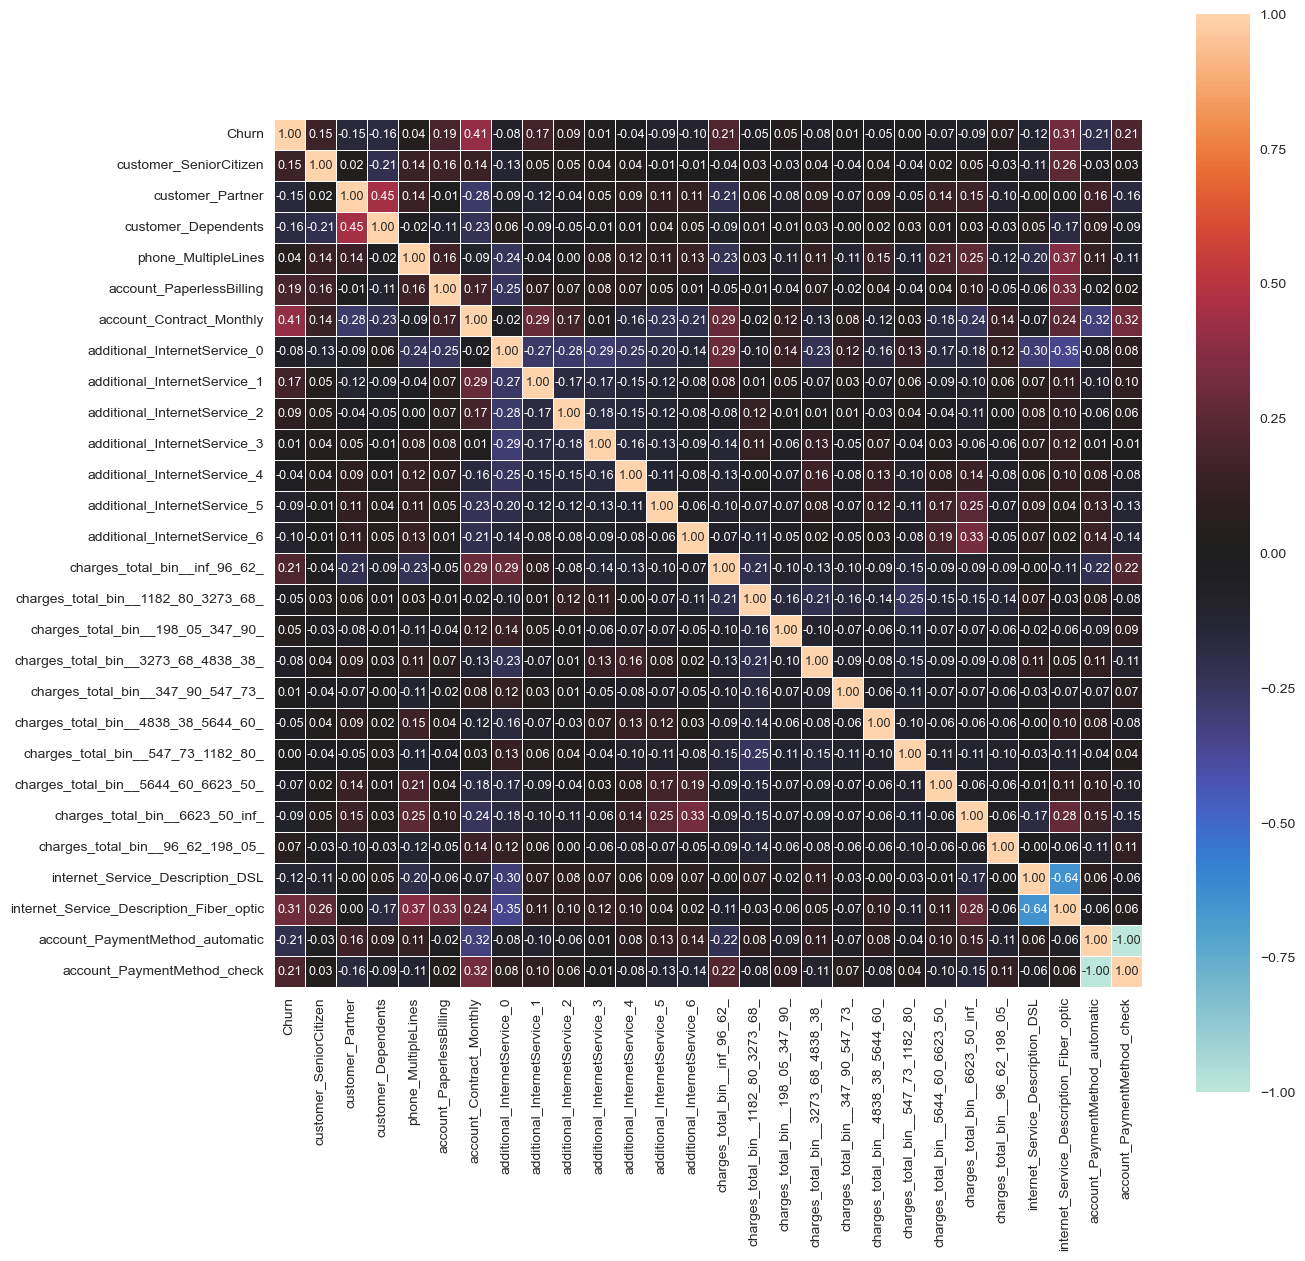

In [107]:
tml.graf_correlacao_variaveis(df_ohe, df_ohe.columns, tam_figura=(14,14), tam_fonte=9).show()

# 📌 Seleção e validação dos modelos de treinamento

## Tabela de verificação de padronização dos dados

| Modelo                 | Precisa padronizar? | Tipo de padronização (se necessário)   |
| ---------------------- | ------------------- | -------------------------------------- |
| DecisionTreeClassifier | ❌ Não               | —                                      |
| LogisticRegression     | ✅ Sim               | `StandardScaler` (média 0, desvio 1)   |
| RandomForest           | ❌ Não               | —                                      |
| XGBoost                | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| LightGBM               | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| CatBoost               | ❌ Não               | —                                      |


## Conceitos sobre as métricas de um modelo

Aqui está o quadro comparativo para churn (evasão de clientes), considerando que a classe positiva é “cliente vai sair”:

| **Métrica**                | **O que mede**                                                                     | **Quando valor é alto**                                        | **Risco quando valor é baixo**                                   | **Custo de erro associado**                                                |
| -------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Precisão (Precision)**   | Entre todos que o modelo previu como “vai sair”, qual porcentagem realmente saiu   | Você gasta retenção apenas em quem de fato sairia              | Gastar recursos em retenção de clientes que iam ficar (FP alto)  | **Custo financeiro** com campanhas desnecessárias (descontos, bônus, etc.) |
| **Recall (Sensibilidade)** | Entre todos que realmente saíram, qual porcentagem o modelo previu como “vai sair” | Você identifica a maior parte dos clientes que iam sair        | Deixar escapar clientes que saem (FN alto)                       | **Perda de receita** e potencial perda de market share                     |
| **F1-Score**               | Média harmônica de precisão e recall                                               | Equilíbrio entre acertar quem vai sair e evitar falsos alarmes | Ou alto custo de retenção inútil ou perda de clientes — ou ambos | **Equilíbrio financeiro e estratégico** — custo total menor                |
| **FP (Falso Positivo)**    | Previu saída, mas o cliente ficaria                                                | —                                                              | Gastar para reter quem não ia sair                               | Desperdício de budget de retenção                                          |
| **FN (Falso Negativo)**    | Previu permanência, mas o cliente saiu                                             | —                                                              | Não agir para reter quem realmente sairia                        | Perda direta de receita + possível impacto na reputação                    |
    

📌 Resumo visual da prioridade

    Se retenção for muito cara → priorizar alta precisão.

    Se perder clientes for muito prejudicial → priorizar alto recall.

    Se quer balancear ambos → otimizar F1-Score.

## Split base de dados em train e test

In [108]:
X = df_ohe.drop(columns=['Churn'])

In [109]:
y = df_ohe.Churn

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = NUM_SEMENTE_ALEATORIA, test_size=TAMANHO_TESTE, stratify=y)

## Treinamento do Modelo - RandomForestClassifier

In [111]:
model_rfc = RandomForestClassifier(max_depth=10, random_state=NUM_SEMENTE_ALEATORIA)
model_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

### Otimizando os hiperparâmetros com o GridSearchCV

Melhores parâmetros com base nas análises realizadas no notebook `TelecomX-RandomForest.ipynb`

In [112]:
best_params_ = {
    "bootstrap": [False],
    "class_weight": ["balanced"],
    "max_depth": [10],
    "min_samples_leaf": [2],
    "min_samples_split": [7],
    "n_estimators": [100]
}

In [113]:
model_grid_rfc = GridSearchCV(
    estimator=model_rfc,
    param_grid=best_params_,
    scoring='recall',  # ou 'f1', 'roc_auc'
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [114]:
model_grid_rfc.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=10, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [False], 'class_weight': ['balanced'],
                         'max_depth': [10], 'min_samples_leaf': [2],
                         'min_samples_split': [7], 'n_estimators': [100]},
             scoring='recall', verbose=2)

In [115]:
y_pred_grid_rfc = model_grid_rfc.predict(X_test)

In [116]:
y_pred_proba_grid_rfc = model_grid_rfc.predict_proba(X_test)

### Relatório de métricas

In [117]:
tml.df_classifier_metrics(y_test, y_pred_grid_rfc, y_pred_proba_grid_rfc, ['RandomForest - Grid'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
RandomForest - Grid,0.732134,0.497055,0.752228,0.598582,0.822486,2113,1125,427,139,422


Métricas:
Acurácia: 0.7321
Precisão: 0.4971
Recall: 0.7522
F1-Score: 0.5986
ROC AUC: 0.8225

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1552
           1       0.50      0.75      0.60       561

    accuracy                           0.73      2113
   macro avg       0.69      0.74      0.70      2113
weighted avg       0.79      0.73      0.75      2113


Matrix de confusão:

[[1125  427]
 [ 139  422]]


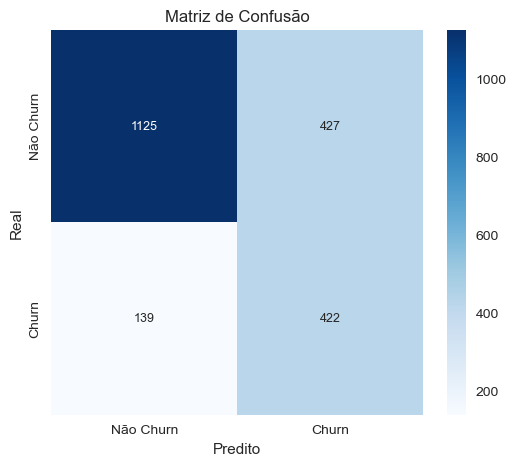

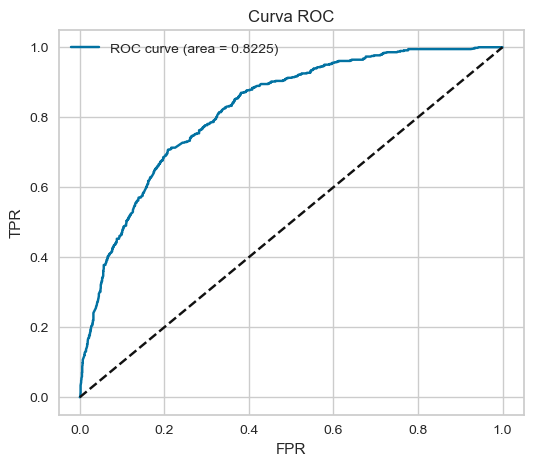

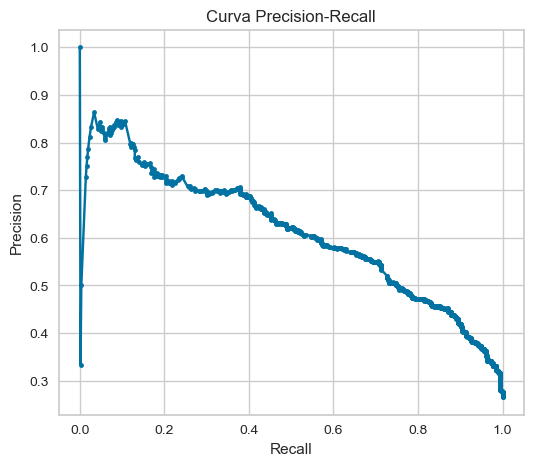

In [118]:
tml.avaliar_modelo(y_test, y_pred_grid_rfc, y_pred_proba_grid_rfc, True)

In [119]:
list_df = []
colunas_binarias = lt.get_columns_binary(X_test)
for c in colunas_binarias:
    list_df.append(tml.df_specific_confusion_matrix(X_test, y_test, y_pred_grid_rfc, c))
df_independent = pd.concat(list_df, axis=0)

In [120]:
df_independent

,filter_value,support,accuracy,negative predictive value,precision,recall,f1-score,TN,FP,FN,TP
customer_SeniorCitizen,1,349,0.687679,0.841727,0.585714,0.848276,0.692958,117,87,22,123
customer_Partner,1,1032,0.794574,0.893130,0.479675,0.584158,0.526786,702,128,84,118
customer_Dependents,1,616,0.827922,0.909980,0.428571,0.494505,0.459184,465,60,46,45
phone_MultipleLines,1,883,0.733862,0.875969,0.534060,0.753846,0.625199,452,171,64,196
account_PaperlessBilling,1,1213,0.696620,0.875639,0.528754,0.819307,0.642718,514,295,73,331
account_Contract_Monthly,1,1182,0.586294,0.792398,0.502381,0.855984,0.633158,271,418,71,422
additional_InternetService_0,1,676,0.782544,0.937360,0.480349,0.797101,0.599455,419,119,28,110
additional_InternetService_1,1,297,0.575758,0.777778,0.521368,0.897059,0.659459,49,112,14,122
additional_InternetService_2,1,291,0.635739,0.811475,0.508876,0.788991,0.618705,99,83,23,86
additional_InternetService_3,1,318,0.742138,0.862944,0.545455,0.709677,0.616822,170,55,27,66


### Salvando modelo

In [121]:
import pickle

In [123]:
with open('./modelos/model_grid_rfc.pkl', 'wb') as arquivo:
    pickle.dump(model_grid_rfc, arquivo)